In [1]:
!pip install opendatasets

  Using cached opendatasets-0.1.22-py3-none-any.whl.metadata (9.2 kB)
Using cached opendatasets-0.1.22-py3-none-any.whl (15 kB)


In [2]:
import opendatasets as od
import os
import shutil

# Tải dataset từ Kaggle
dataset_url = 'https://www.kaggle.com/datasets/splcher/animefacedataset'
od.download(dataset_url)

# PyTorch ImageFolder yêu cầu ảnh phải nằm trong một thư mục con.
# Ta sẽ tạo thư mục 'anime_data/images' và di chuyển ảnh vào đó.
os.makedirs('anime_data/images', exist_ok=True)
source_dir = 'animefacedataset/images'
dest_dir = 'anime_data/images'

if os.path.exists(source_dir):
    for filename in os.listdir(source_dir):
        shutil.move(os.path.join(source_dir, filename), os.path.join(dest_dir, filename))
    print("Đã chuẩn bị xong thư mục dữ liệu!")
else:
    print("Dữ liệu đã được sắp xếp sẵn.")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dcgan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/splcher/animefacedataset


100%|██████████| 395M/395M [00:02<00:00, 174MB/s]



Đã chuẩn bị xong thư mục dữ liệu!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Kiểm tra xem GPU đã sẵn sàng chưa
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Đang chạy trên:", device)

# Cấu hình siêu tham số
image_size = 64
batch_size = 128

# Chuẩn bị dữ liệu: Cắt ảnh về 64x64 và chuẩn hóa màu sắc về khoảng [-1, 1]
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Nạp dữ liệu
dataset = dset.ImageFolder(root='anime_data', transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Tổng số ảnh có trong dataset: {len(dataset)}")

Đang chạy trên: cuda
Tổng số ảnh có trong dataset: 63565


In [4]:
# Hàm khởi tạo trọng số chuyên dụng cho DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Kích thước vector nhiễu đầu vào
nz = 100

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Khối 1: Input 100 -> 4x4
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # Khối 2: 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # Khối 3: 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Khối 4: 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Khối 5: 32x32 -> 64x64 (Xuất ra 3 kênh màu RGB)
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Khởi tạo Generator
netG = Generator().to(device)
netG.apply(weights_init)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input là ảnh màu (3 kênh) kích thước 64x64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Khối 2: 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # Khối 3: 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # Khối 4: 8x8 -> 4x4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # Khối 5: 4x4 -> 1x1 (Xác suất thật/giả)
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

# Khởi tạo Discriminator
netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [6]:
# Hàm tính lỗi Binary Cross Entropy (chuẩn cho GAN)
criterion = nn.BCELoss()

# Tạo một vector nhiễu cố định để theo dõi tiến trình sinh ảnh
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Thuật toán tối ưu Adam cho cả 2 mạng
lr = 0.0002
beta1 = 0.5
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [7]:
num_epochs = 30 # Chạy 30 vòng (khoảng 2-3 tiếng)
G_losses = []
D_losses = []
img_list = []

print("Bắt đầu huấn luyện...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):

        # -----------------------------
        # 1. Huấn luyện Discriminator (Cảnh sát)
        # -----------------------------
        netD.zero_grad()

        # Dạy cảnh sát nhận biết ảnh thật
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label_real = torch.full((b_size,), 1.0, dtype=torch.float, device=device)

        output_real = netD(real_cpu)
        errD_real = criterion(output_real, label_real)
        errD_real.backward()

        # Dạy cảnh sát nhận biết ảnh giả
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label_fake = torch.full((b_size,), 0.0, dtype=torch.float, device=device)

        output_fake = netD(fake.detach())
        errD_fake = criterion(output_fake, label_fake)
        errD_fake.backward()

        optimizerD.step()
        errD = errD_real + errD_fake

        # -----------------------------
        # 2. Huấn luyện Generator (Kẻ làm giả)
        # -----------------------------
        netG.zero_grad()

        # Generator muốn lừa Discriminator, nên nó gán nhãn ảnh giả của nó là "Thật" (1.0)
        label_g = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        output = netD(fake)
        errG = criterion(output, label_g)
        errG.backward()

        optimizerG.step()

        # In tiến trình ra màn hình
        if i % 100 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

        # Lưu lại Loss để vẽ biểu đồ
        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # Lưu lại ảnh do Generator sinh ra ở mỗi Epoch để xem nó tiến bộ thế nào
    with torch.no_grad():
        fake_display = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake_display, padding=2, normalize=True))

    # LƯU CHECKPOINT ĐỀ PHÒNG MẤT ĐIỆN / MẤT MẠNG
    torch.save(netG.state_dict(), 'generator_anime.pth')

print("Hoàn tất huấn luyện!")

Bắt đầu huấn luyện...
[0/30][0/497] Loss_D: 1.6733 Loss_G: 2.7187
[0/30][100/497] Loss_D: 0.5501 Loss_G: 5.3098
[0/30][200/497] Loss_D: 0.3310 Loss_G: 3.9269
[0/30][300/497] Loss_D: 0.5827 Loss_G: 5.8061
[0/30][400/497] Loss_D: 1.0782 Loss_G: 8.8123
[1/30][0/497] Loss_D: 0.4439 Loss_G: 5.0961
[1/30][100/497] Loss_D: 0.2589 Loss_G: 6.3026
[1/30][200/497] Loss_D: 0.6840 Loss_G: 5.2697
[1/30][300/497] Loss_D: 0.7238 Loss_G: 4.8693
[1/30][400/497] Loss_D: 1.1900 Loss_G: 10.9210
[2/30][0/497] Loss_D: 0.4199 Loss_G: 3.9817
[2/30][100/497] Loss_D: 0.8608 Loss_G: 6.9734
[2/30][200/497] Loss_D: 0.5406 Loss_G: 4.7787
[2/30][300/497] Loss_D: 0.2051 Loss_G: 4.1840
[2/30][400/497] Loss_D: 0.2814 Loss_G: 5.1305
[3/30][0/497] Loss_D: 0.4450 Loss_G: 4.0845
[3/30][100/497] Loss_D: 0.4526 Loss_G: 7.4024
[3/30][200/497] Loss_D: 0.5195 Loss_G: 4.9862
[3/30][300/497] Loss_D: 0.1619 Loss_G: 4.1332
[3/30][400/497] Loss_D: 0.2670 Loss_G: 3.9263
[4/30][0/497] Loss_D: 0.1400 Loss_G: 6.1433
[4/30][100/497] Loss_

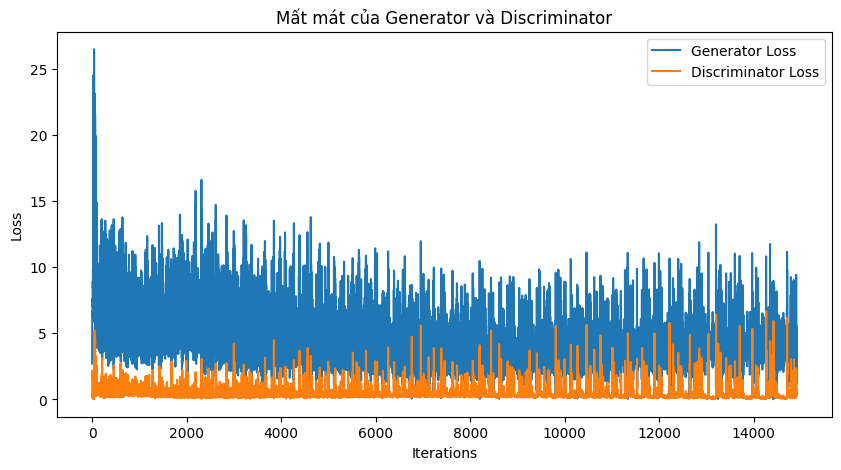

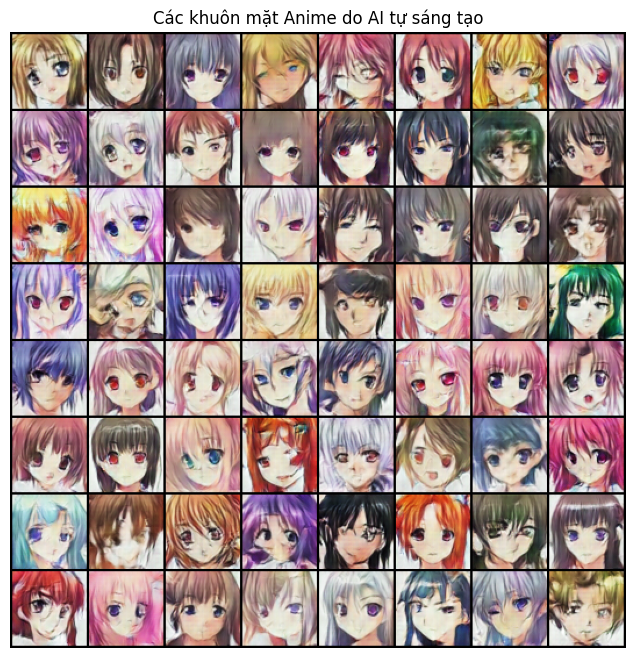

In [8]:
# 1. Vẽ đồ thị Loss
plt.figure(figsize=(10,5))
plt.title("Mất mát của Generator và Discriminator")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 2. Hiển thị ảnh sinh ra ở vòng cuối cùng
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Các khuôn mặt Anime do AI tự sáng tạo")
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
plt.show()